Correlation Analysis in Python

Understanding Correlation Fundamentals

Correlation analysis measures the strength and direction of relationships between variables in statistical data. The concept is fundamental in data science for identifying patterns, making predictions, and understanding variable dependencies in complex datasets.

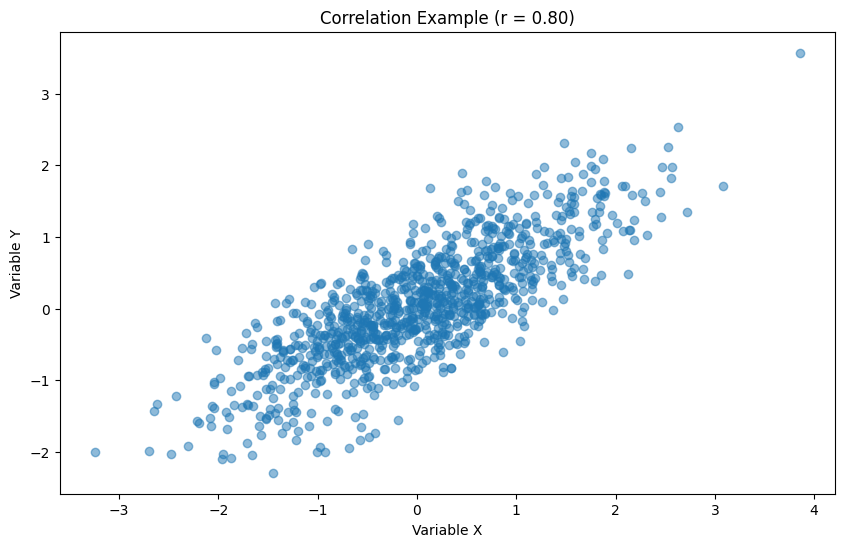

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate sample data
np.random.seed(42)
x = np.random.normal(0, 1, 1000)
y = 0.7 * x + np.random.normal(0, 0.5, 1000)  # Positive correlation

# Calculate Pearson correlation
correlation = np.corrcoef(x, y)[0, 1]

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)
plt.title(f'Correlation Example (r = {correlation:.2f})')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.show()

Types of Correlation

Statistical correlation can manifest in three primary forms: positive correlation where variables increase together, negative correlation where one increases as the other decreases, and zero correlation indicating no relationship between variables.

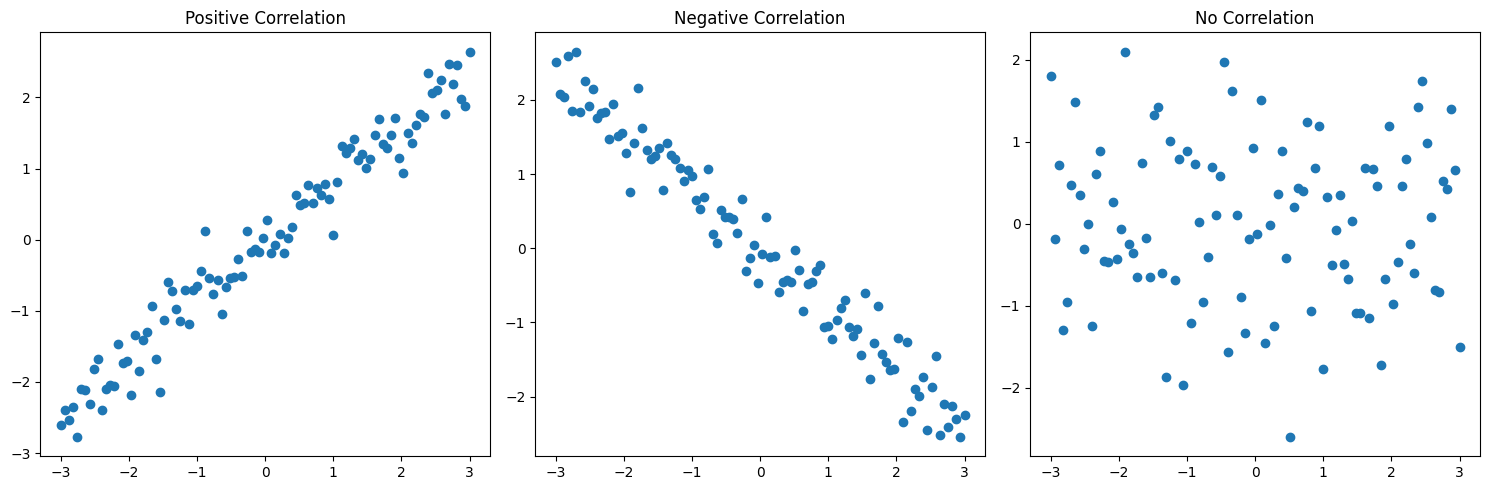

In [2]:
# Generate different correlation types
x = np.linspace(-3, 3, 100)
y_positive = 0.8 * x + np.random.normal(0, 0.3, 100)
y_negative = -0.8 * x + np.random.normal(0, 0.3, 100)
y_zero = np.random.normal(0, 1, 100)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(x, y_positive)
ax1.set_title('Positive Correlation')

ax2.scatter(x, y_negative)
ax2.set_title('Negative Correlation')

ax3.scatter(x, y_zero)
ax3.set_title('No Correlation')

plt.tight_layout()
plt.show()

Pearson Correlation Coefficient

The Pearson correlation coefficient quantifies linear relationships between continuous variables, producing values between -1 and 1. This mathematical formula represents the covariance of variables divided by the product of their standard deviations.

In [3]:
def pearson_correlation(x, y):
    """
    Calculate Pearson correlation coefficient from scratch
    """
    x_mean, y_mean = np.mean(x), np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator

# Example calculation
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])
correlation = pearson_correlation(x, y)
print(f"Correlation coefficient: {correlation:.4f}")

Correlation coefficient: 0.7746


Marketing Analytics Case Study - Data Preparation

A real-world marketing dataset analyzing the relationship between advertising spend and sales across different channels. This comprehensive analysis helps identify the most effective marketing channels for budget allocation.

In [4]:
# Create sample marketing dataset
np.random.seed(42)
n_samples = 1000

data = {
    'tv_spend': np.random.uniform(10000, 100000, n_samples),
    'social_media_spend': np.random.uniform(5000, 50000, n_samples),
    'email_spend': np.random.uniform(1000, 20000, n_samples)
}

# Generate sales with realistic correlations
data['sales'] = (
    0.6 * data['tv_spend'] +
    0.3 * data['social_media_spend'] +
    0.1 * data['email_spend'] +
    np.random.normal(0, 10000, n_samples)
)

df = pd.DataFrame(data)
print(df.head())
print("\nData Summary:")
print(df.describe())

       tv_spend  social_media_spend   email_spend         sales
0  43708.610696        13330.981798   5972.407991  41421.065597
1  95564.287577        29385.542632   5692.597182  72893.554550
2  75879.454763        44282.562614  18218.837030  67470.018577
3  63879.263578        37950.119888   5741.377797  36627.174781
4  24041.677640        41295.251654   6167.044796  39549.726414

Data Summary:
           tv_spend  social_media_spend   email_spend         sales
count   1000.000000         1000.000000   1000.000000   1000.000000
mean   54123.089799        27815.778733  10545.708796  41896.027209
std    26292.362575        13148.545203   5522.809714  18869.616984
min    10416.882070         5144.821862   1000.221060 -10990.203879
25%    31237.594083        15848.342202   5965.668567  28152.103643
50%    54712.663889        28343.025789  10511.664473  41855.750168
75%    76988.762918        39220.927581  15422.967022  56342.832759
max    99974.590596        49973.617660  19958.596258  93

Marketing Analytics Case Study - Correlation Analysis

Analyzing correlations between different marketing channels and sales reveals the effectiveness of each channel. This analysis guides marketing budget optimization and helps identify synergies between channels.

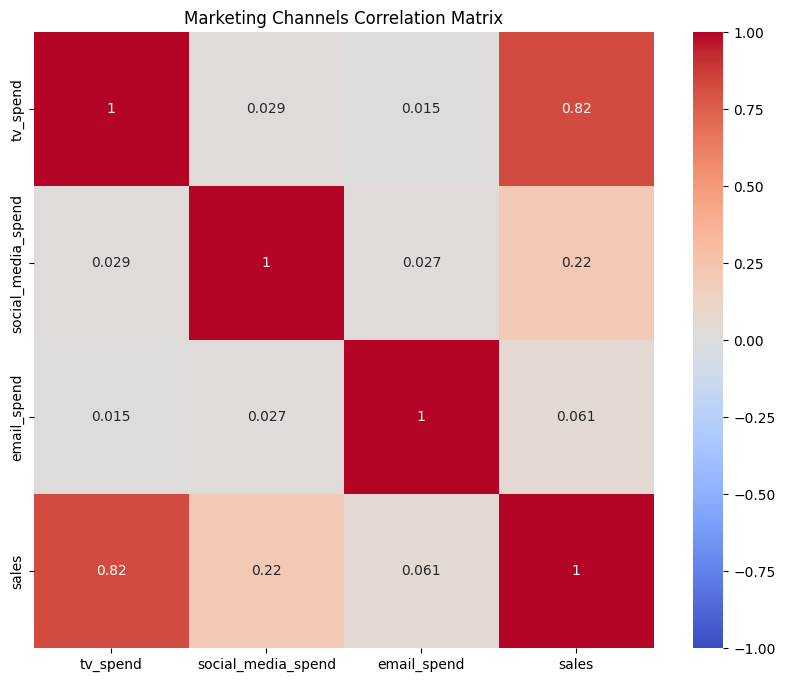


Correlations with Sales:
sales                 1.000000
tv_spend              0.823405
social_media_spend    0.217769
email_spend           0.060994
Name: sales, dtype: float64


In [5]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0)
plt.title('Marketing Channels Correlation Matrix')
plt.show()

# Calculate and display channel-to-sales correlations
channel_correlations = correlation_matrix['sales'].sort_values(ascending=False)
print("\nCorrelations with Sales:")
print(channel_correlations)

Nonlinear Correlation Analysis

Traditional Pearson correlation fails to capture nonlinear relationships. Spearman and Kendall correlation coefficients provide alternative measures for monotonic relationships that may not be strictly linear.

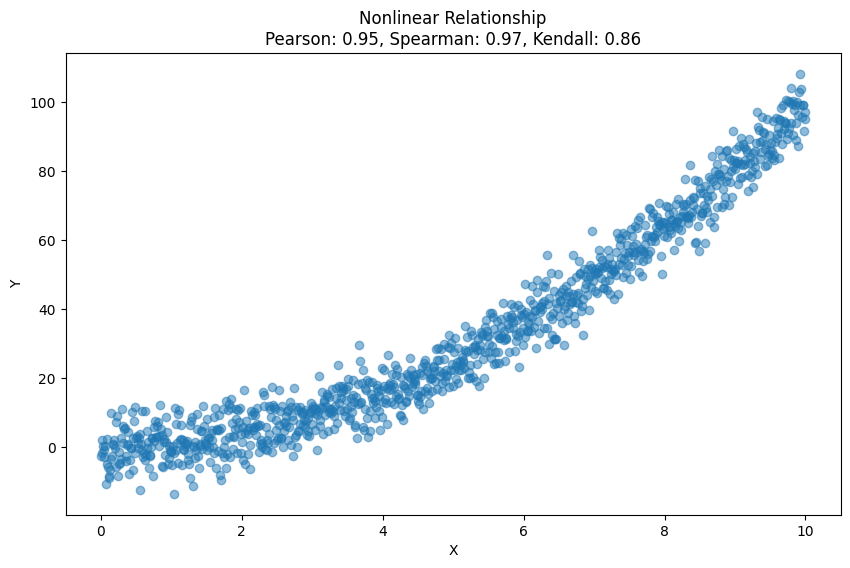

In [6]:
# Generate nonlinear relationship
x = np.linspace(0, 10, 1000)
y = x**2 + np.random.normal(0, 5, 1000)

# Calculate different correlation coefficients
pearson_corr = np.corrcoef(x, y)[0,1]
spearman_corr = pd.Series(x).corr(pd.Series(y), method='spearman')
kendall_corr = pd.Series(x).corr(pd.Series(y), method='kendall')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)
plt.title(f'Nonlinear Relationship\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}, Kendall: {kendall_corr:.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

Advanced Correlation Matrix Visualization

Correlation matrix visualization provides insights into relationships between multiple variables simultaneously. This advanced implementation includes hierarchical clustering to group related variables and customizable visualization parameters for enhanced interpretation.


Correlation Matrix:
       var1   var2   var3   var4
var1  1.000 -0.136  0.191  0.914
var2 -0.136  1.000 -0.037 -0.142
var3  0.191 -0.037  1.000  0.188
var4  0.914 -0.142  0.188  1.000


<Figure size 1000x800 with 0 Axes>

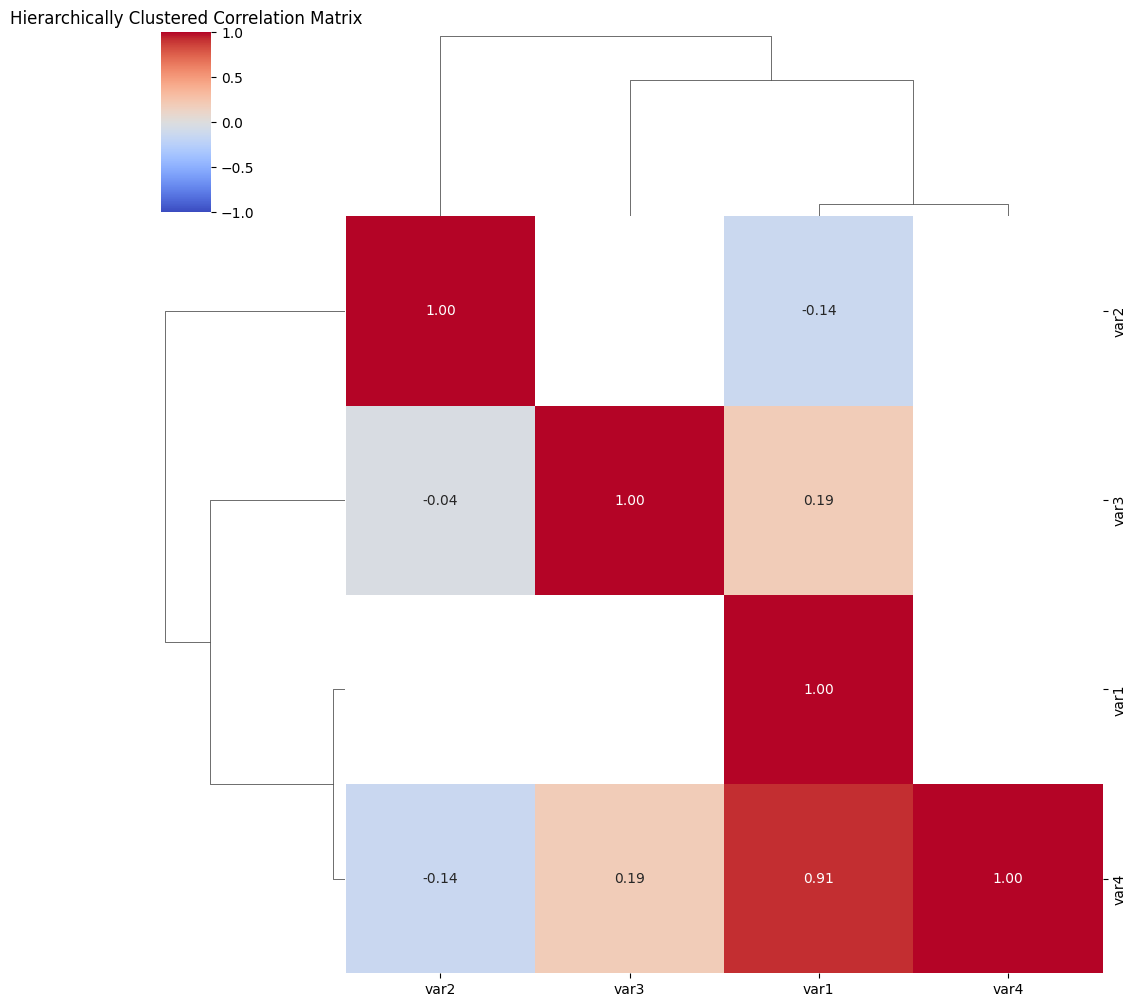

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.stats import spearmanr

def plot_corr_matrix(data, method='pearson', figsize=(10, 8)):
    # Calculate correlation matrix
    corr = data.corr(method=method)
    
    # Generate mask for upper triangle
    mask = np.triu(np.ones_like(corr), k=1)
    
    # Create clustered heatmap
    plt.figure(figsize=figsize)
    sns.clustermap(corr,
                  annot=True,
                  fmt='.2f',
                  cmap='coolwarm',
                  center=0,
                  vmin=-1,
                  vmax=1,
                  mask=mask)
    plt.title('Hierarchically Clustered Correlation Matrix')
    return corr

# Example usage
np.random.seed(42)
n_samples = 100
data = pd.DataFrame({
    'var1': np.random.normal(0, 1, n_samples),
    'var2': np.random.normal(0, 1, n_samples),
    'var3': np.random.normal(0, 1, n_samples)
})
data['var4'] = 0.7 * data['var1'] + np.random.normal(0, 0.3, n_samples)

correlation_matrix = plot_corr_matrix(data)
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

Time Series Correlation Analysis

Time series correlation analysis examines relationships between variables across different time periods, incorporating lag effects and temporal dependencies to understand dynamic relationships in sequential data.

Lag Correlations: {0: np.float64(0.8510224216085741), 1: np.float64(0.8556589396033876), 2: np.float64(0.8618538129061978), 3: np.float64(0.8669911178511573), 4: np.float64(0.8716757611073129), 5: np.float64(0.875135245767681)}


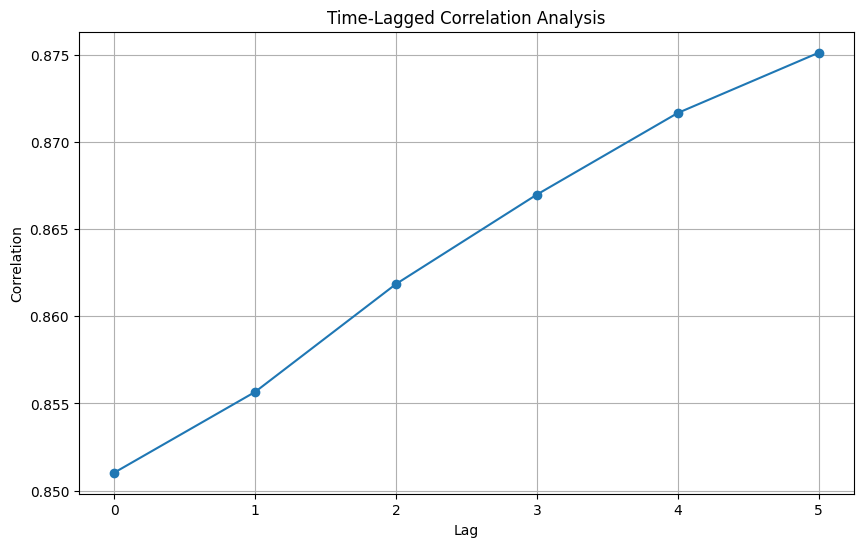

In [9]:
def analyze_time_correlation(series1, series2, max_lag=5):
    correlations = []
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = np.corrcoef(series1, series2)[0,1]
        else:
            corr = np.corrcoef(series1[lag:], series2[:-lag])[0,1]
        correlations.append((lag, corr))
    return correlations

# Generate time series data
t = np.linspace(0, 10, 1000)
series1 = np.sin(t) + np.random.normal(0, 0.1, len(t))
series2 = np.sin(t + 0.5) + np.random.normal(0, 0.1, len(t))

# Calculate lagged correlations
lag_correlations = analyze_time_correlation(series1, series2)

# Plot results
plt.figure(figsize=(10, 6))
lags, corrs = zip(*lag_correlations)
plt.plot(lags, corrs, 'o-')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.title('Time-Lagged Correlation Analysis')
plt.grid(True)
print("Lag Correlations:", dict(lag_correlations))

Robust Correlation Methods

Robust correlation methods handle outliers and non-normal distributions effectively. These techniques provide reliable correlation estimates when data violates assumptions of traditional Pearson correlation.

In [16]:
import numpy as np
from scipy.stats import spearmanr, kendalltau  # Add this line

def robust_correlation(x, y, method='spearman'):
    if method == 'spearman':
        corr, p_value = spearmanr(x, y)
    elif method == 'kendall':
        corr, p_value = kendalltau(x, y)
    else:
        raise ValueError("Method must be 'spearman' or 'kendall'")
    return corr, p_value

# Generate data with outliers
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 0.8 * x + np.random.normal(0, 0.2, 100)
# Add outliers
x[0] = 10
y[0] = -10

# Compare correlation methods
methods = ['pearson', 'spearman', 'kendall']
results = {}

for method in methods:
    if method == 'pearson':
        corr = np.corrcoef(x, y)[0,1]
    else:
        corr, _ = robust_correlation(x, y, method)
    results[method] = corr

print("Correlation Results:")
for method, corr in results.items():
    print(f"{method.capitalize()}: {corr:.3f}")

Correlation Results:
Pearson: -0.220
Spearman: 0.906
Kendall: 0.805


Correlation Significance Testing

Statistical significance testing for correlations determines whether observed relationships are likely to occur by chance. This implementation includes p-value calculation and confidence interval estimation.

In [13]:
def correlation_significance(x, y, alpha=0.05):
    n = len(x)
    r = np.corrcoef(x, y)[0,1]
    
    # Calculate t-statistic
    t = r * np.sqrt((n-2)/(1-r**2))
    
    # Calculate p-value
    from scipy.stats import t as t_dist
    p_value = 2 * (1 - t_dist.cdf(abs(t), n-2))
    
    # Calculate confidence interval
    z = np.arctanh(r)
    se = 1/np.sqrt(n-3)
    ci_lower = np.tanh(z - se * 1.96)
    ci_upper = np.tanh(z + se * 1.96)
    
    return {
        'correlation': r,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'significant': p_value < alpha
    }

# Example usage
x = np.random.normal(0, 1, 100)
y = 0.3 * x + np.random.normal(0, 0.9, 100)

results = correlation_significance(x, y)
for key, value in results.items():
    print(f"{key}: {value:.4f}")

correlation: 0.3782
p_value: 0.0001
ci_lower: 0.1964
ci_upper: 0.5349
significant: 1.0000


Distance Correlation Analysis

Distance correlation measures dependence between variables of different dimensions, capturing both linear and nonlinear relationships. This implementation provides a more general measure of statistical dependence.



In [14]:
def distance_correlation(x, y):
    x = np.atleast_1d(x)
    y = np.atleast_1d(y)
    
    if x.shape[0] != y.shape[0]:
        raise ValueError('Arrays must have same length')
        
    n = x.shape[0]
    
    # Calculate distance matrices
    def dist_matrix(arr):
        return np.sqrt(np.sum((arr[:,None] - arr)**2, axis=-1))
    
    dx = dist_matrix(x.reshape(-1,1))
    dy = dist_matrix(y.reshape(-1,1))
    
    # Double center distance matrices
    def double_center(D):
        row_mean = D.mean(axis=0)
        col_mean = D.mean(axis=1)
        total_mean = D.mean()
        return D - row_mean - col_mean[:,None] + total_mean
    
    dcx = double_center(dx)
    dcy = double_center(dy)
    
    # Calculate distance correlation
    dcov = (dcx * dcy).mean()
    dvarx = (dcx * dcx).mean()
    dvary = (dcy * dcy).mean()
    
    return np.sqrt(dcov) / np.sqrt(np.sqrt(dvarx * dvary))

# Example with nonlinear relationship
x = np.random.uniform(0, 2*np.pi, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

dc = distance_correlation(x, y)
pc = np.corrcoef(x, y)[0,1]

print(f"Distance Correlation: {dc:.4f}")
print(f"Pearson Correlation: {pc:.4f}")

Distance Correlation: 0.8645
Pearson Correlation: -0.7980


Partial Correlation Analysis

Partial correlation measures the relationship between two variables while controlling for the effects of other variables, revealing direct relationships in multivariate systems.

In [15]:
def partial_correlation(data, x, y, controlling_vars):
    def residuals(a, b):
        slope, intercept = np.polyfit(b, a, 1)
        return a - (slope * b + intercept)
    
    x_resid = data[x]
    y_resid = data[y]
    
    for control in controlling_vars:
        x_resid = residuals(x_resid, data[control])
        y_resid = residuals(y_resid, data[control])
    
    return np.corrcoef(x_resid, y_resid)[0,1]

# Example dataset
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    'x': np.random.normal(0, 1, n),
    'y': np.random.normal(0, 1, n),
    'z': np.random.normal(0, 1, n)
})
data['y'] = 0.5 * data['x'] + 0.3 * data['z'] + np.random.normal(0, 0.5, n)

# Calculate correlations
regular_corr = np.corrcoef(data['x'], data['y'])[0,1]
partial_corr = partial_correlation(data, 'x', 'y', ['z'])

print(f"Regular correlation: {regular_corr:.4f}")
print(f"Partial correlation (controlling for z): {partial_corr:.4f}")

Regular correlation: 0.6334
Partial correlation (controlling for z): 0.6848


Additional Resources

https://arxiv.org/abs/2007.02731 - "Robust Correlation Analysis: A Review of Recent Developments with Applications to Data Science" https://arxiv.org/abs/1804.02532 - "Distance Correlation: A New Tool for Detecting Association and Measuring Correlation Between Data Sets" https://arxiv.org/abs/1909.10140 - "Modern Applications of Correlation Analysis in Time Series Data" https://arxiv.org/abs/2103.05825 - "Partial Correlation in High-Dimensional Data Analysis"